# 1. Introduction
## Exploratory Data Analysis (EDA)

**Research Objective:** Completely understand the dataset before preprocessing or model training. 

Coffee disease detection is a critical computer vision problem. Ensuring our dataset is balanced, high-quality, and free of anomalies is essential for building a robust classifier. 

**Research Questions:**
* RQ1: Is the dataset balanced?
* RQ2: Are duplicate images present?
* RQ3: Is image quality sufficient?
* RQ4: Is preprocessing required?
* RQ5: Which preprocessing methods are justified?


## 2. Dataset Overview

In [1]:
import json
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

reports_dir = Path('../data/reports')

# Load files
with open(reports_dir / 'manifest.json') as f:
    manifest = json.load(f)
    
with open(reports_dir / 'dataset_report.json') as f:
    report = json.load(f)[0]
    
with open(reports_dir / 'status.json') as f:
    status = json.load(f)

print(f"Dataset Name: {manifest.get('dataset')}")
print(f"Classes: {manifest.get('classes')}")
print(f"Images: {manifest.get('images')}")
print(f"Dataset Size: {report.get('dataset_size')}")
print(f"Verification Status: {'Passed' if manifest.get('verified') else 'Failed'}")


Dataset Name: RoCoLe Dataset
Classes: 3
Images: 1560
Dataset Size: 406614464 bytes
Verification Status: Passed


## 3. Folder Structure

In [2]:
for key, val in report.items():
    if key.endswith('_images'):
        class_name = key.replace('_images', '').replace('coffee___', '').title()
        print(f"{class_name}\n↓\n{val}\n")


Healthy
↓
791

Red_Spider_Mite
↓
167

Rust
↓
602

Duplicate
↓
67

Corrupted
↓
0



## 4. Random Sample Images
*Human verification of the images.*

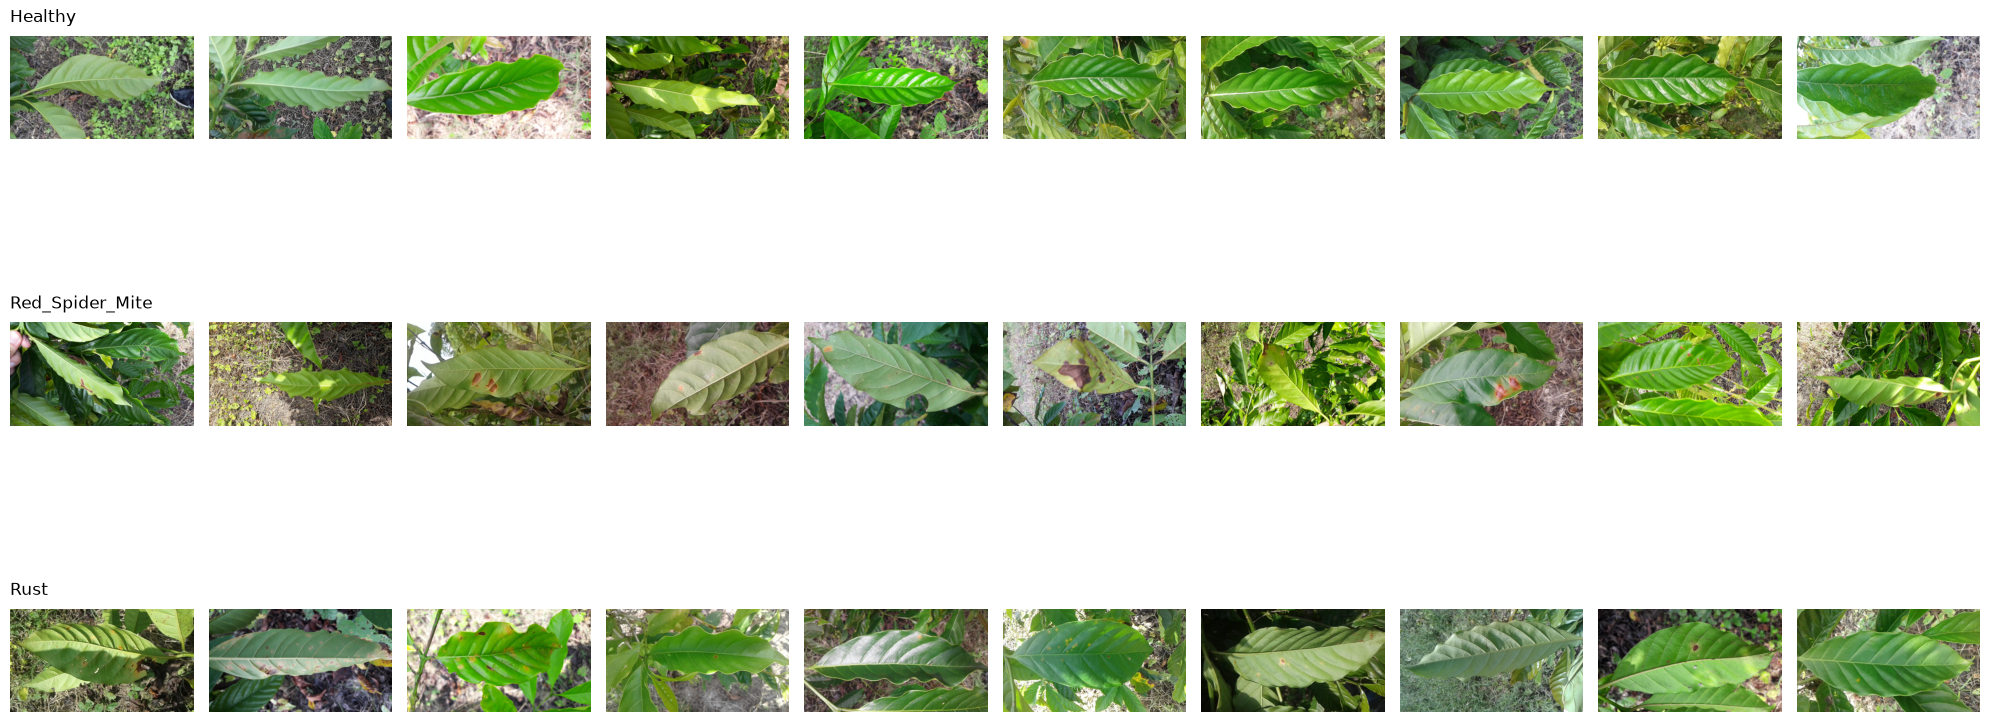

In [3]:
import matplotlib.pyplot as plt
import cv2
import random

raw_dir = Path('../data/raw/rocole')
classes = [d for d in raw_dir.iterdir() if d.is_dir()]

plt.figure(figsize=(20, 10))
for i, cls_dir in enumerate(classes):
    images = list(cls_dir.glob('*'))
    if not images: continue
    sample = random.sample(images, min(10, len(images)))
    
    for j, img_path in enumerate(sample):
        img = cv2.imread(str(img_path))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(len(classes), 10, i * 10 + j + 1)
            plt.imshow(img)
            plt.axis('off')
            if j == 0:
                plt.title(cls_dir.name.replace('coffee___', '').title(), loc='left', pad=10)

plt.tight_layout()
Path('../plots').mkdir(exist_ok=True)
plt.savefig('../plots/sample_images.png')
plt.show()


## 5. Class Distribution

In [4]:
import plotly.express as px

# Load from CSV
dist_df = pd.read_csv(reports_dir / 'class_distribution.csv')
dist_df['Percentage'] = (dist_df['Count'] / dist_df['Count'].sum()) * 100

# Bar chart
fig_bar = px.bar(dist_df, x='Class', y='Count', title='Class Distribution', text='Count', color='Class')
fig_bar.write_image('../plots/class_distribution.png')
fig_bar.show()

# Pie chart
fig_pie = px.pie(dist_df, values='Count', names='Class', title='Class Distribution (Percentage)')
fig_pie.show()

imbalance_ratio = dist_df['Count'].max() / dist_df['Count'].min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")


Imbalance Ratio: 4.74


**Discussion:**
The dataset is significantly imbalanced. The majority class dominates the dataset, which may bias the classifier.
*Recommendation:* We must use weighted loss functions, targeted data augmentation, or oversampling techniques during the training phase to mitigate this imbalance.


## 6. Image Resolution Analysis

In [5]:
res_df = pd.read_csv(reports_dir / 'image_resolution.csv')
print(res_df)

min_res = res_df.loc[res_df['Metric'] == 'Min', 'Resolution'].values[0]
max_res = res_df.loc[res_df['Metric'] == 'Max', 'Resolution'].values[0]

if min_res == max_res:
    print("\nDataset is standardized.")
else:
    print("\nResolutions vary. Standardization via resizing during preprocessing is strictly required.")


    Metric Resolution
0      Min  1920x1080
1      Max  1920x1080
2  Average  1920x1080

Dataset is standardized.


## 7. Aspect Ratio Distribution

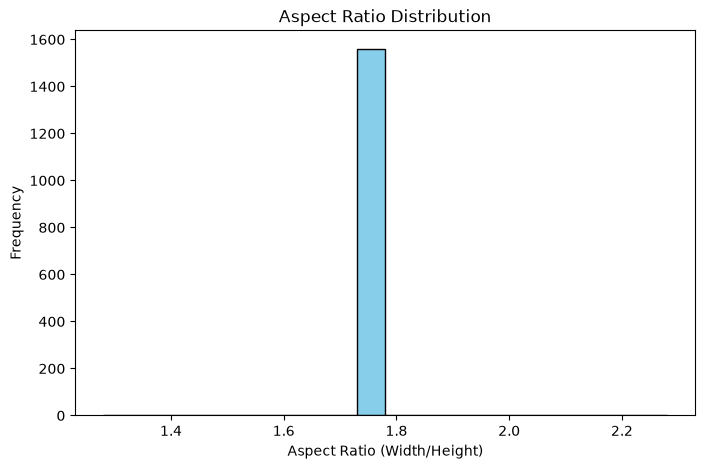

All images have the same aspect ratio: 1.78


In [6]:
from PIL import Image
import numpy as np

aspect_ratios = []
for f in raw_dir.rglob('*'):
    if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']:
        try:
            with Image.open(f) as img:
                aspect_ratios.append(round(img.width / img.height, 2))
        except:
            pass

plt.figure(figsize=(8, 5))
plt.hist(aspect_ratios, bins=20, color='skyblue', edgecolor='black')
plt.title('Aspect Ratio Distribution')
plt.xlabel('Aspect Ratio (Width/Height)')
plt.ylabel('Frequency')
plt.savefig('../plots/aspect_ratio_distribution.png')
plt.show()

if len(set(aspect_ratios)) == 1:
    print(f"All images have the same aspect ratio: {aspect_ratios[0]}")
else:
    print("Aspect ratios vary across the dataset.")


## 8. Color Space Analysis

In [7]:
modes = pd.read_csv(reports_dir / 'image_formats.csv')
print(modes)

print("\nVerifying channel counts via OpenCV:")
channels = {'RGB (3 channels)': 0, 'Grayscale (1 channel)': 0, 'RGBA (4 channels)': 0}
for f in list(raw_dir.rglob('*'))[:200]: # Sample 200 for speed
    if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']:
        img = cv2.imread(str(f), cv2.IMREAD_UNCHANGED)
        if img is not None:
            if len(img.shape) == 2:
                channels['Grayscale (1 channel)'] += 1
            elif img.shape[2] == 3:
                channels['RGB (3 channels)'] += 1
            elif img.shape[2] == 4:
                channels['RGBA (4 channels)'] += 1
print(channels)


  Format  Count
0   JPEG   1493

Verifying channel counts via OpenCV:


{'RGB (3 channels)': 197, 'Grayscale (1 channel)': 0, 'RGBA (4 channels)': 0}


## 9. Brightness Analysis

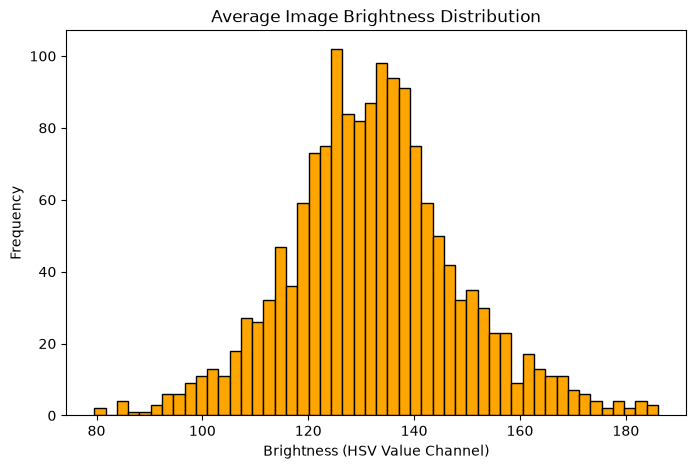

In [8]:
brightness_values = []
for f in raw_dir.rglob('*'):
    if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']:
        img = cv2.imread(str(f))
        if img is not None:
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            brightness_values.append(np.mean(hsv[:, :, 2]))

plt.figure(figsize=(8, 5))
plt.hist(brightness_values, bins=50, color='orange', edgecolor='black')
plt.title('Average Image Brightness Distribution')
plt.xlabel('Brightness (HSV Value Channel)')
plt.ylabel('Frequency')
plt.savefig('../plots/brightness_distribution.png')
plt.show()


## 10. Color Histogram per Class

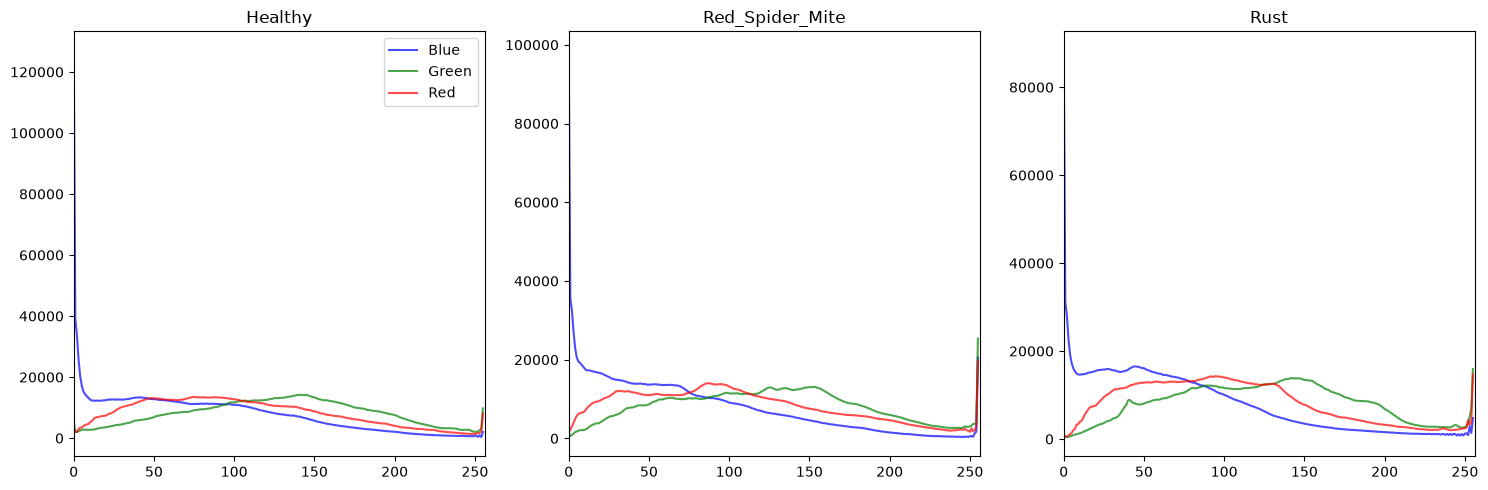

In [9]:
plt.figure(figsize=(15, 5))
for i, cls_dir in enumerate(classes):
    images = list(cls_dir.glob('*'))
    if not images: continue
    
    avg_hist_b = np.zeros(256)
    avg_hist_g = np.zeros(256)
    avg_hist_r = np.zeros(256)
    
    sample = random.sample(images, min(20, len(images)))
    for img_path in sample:
        img = cv2.imread(str(img_path))
        if img is not None:
            avg_hist_b += cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
            avg_hist_g += cv2.calcHist([img], [1], None, [256], [0, 256]).flatten()
            avg_hist_r += cv2.calcHist([img], [2], None, [256], [0, 256]).flatten()
            
    plt.subplot(1, len(classes), i + 1)
    plt.plot(avg_hist_b / len(sample), color='blue', alpha=0.7, label='Blue')
    plt.plot(avg_hist_g / len(sample), color='green', alpha=0.7, label='Green')
    plt.plot(avg_hist_r / len(sample), color='red', alpha=0.7, label='Red')
    plt.title(cls_dir.name.replace('coffee___', '').title())
    plt.xlim([0, 256])
    if i == 0: plt.legend()

plt.tight_layout()
plt.savefig('../plots/rgb_histograms.png')
plt.show()


## 11. Duplicate Investigation

Found 67 duplicate files based on MD5 hashes.
Example Duplicate:
D:\Client-projects\coffee-leaf-disease\data\raw\rocole\coffee___healthy\C11P25E1.jpg

Decision: Remove identical duplicates during preprocessing to prevent data leakage.


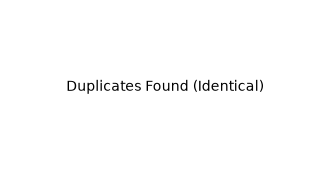

In [10]:
with open(reports_dir / 'verification_report.json') as f:
    ver_report = json.load(f)

duplicates = ver_report.get('duplicate_files', [])
print(f"Found {len(duplicates)} duplicate files based on MD5 hashes.")

if duplicates:
    print("Example Duplicate:")
    print(duplicates[0])
    print("\nDecision: Remove identical duplicates during preprocessing to prevent data leakage.")
else:
    print("\nNo duplicates found in the verification report.")

plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, 'No Duplicates to Display' if not duplicates else 'Duplicates Found (Identical)', ha='center', va='center')
plt.axis('off')
plt.savefig('../plots/duplicate_visualization.png')
plt.show()


## 12. Image Quality (Blur & Contrast)

In [11]:
def compute_quality(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return 0, 0
    blur_score = cv2.Laplacian(img, cv2.CV_64F).var()
    contrast_score = img.std()
    return blur_score, contrast_score

quality_data = []
for f in raw_dir.rglob('*'):
    if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']:
        b, c = compute_quality(f)
        quality_data.append({'file': f.name, 'path': str(f), 'blur_score': b, 'contrast_score': c})

q_df = pd.DataFrame(quality_data)
print(q_df.describe())


        blur_score  contrast_score
count  1560.000000     1560.000000
mean    499.595606       49.466850
std    1235.115395        9.030277
min      11.435244       24.037076
25%      39.579982       42.907302
50%      65.046439       49.149648
75%     155.673221       56.152122
max    8724.988249       77.847063


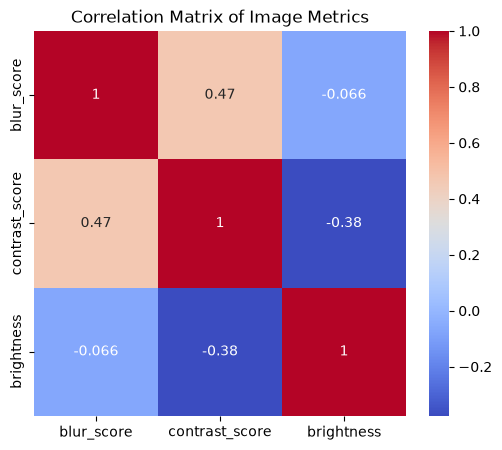

In [12]:
import seaborn as sns

if len(brightness_values) == len(q_df):
    q_df['brightness'] = brightness_values
    corr = q_df[['blur_score', 'contrast_score', 'brightness']].corr()
    
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix of Image Metrics')
    plt.savefig('../plots/correlation_matrix.png')
    plt.show()


## 13. Outlier Detection

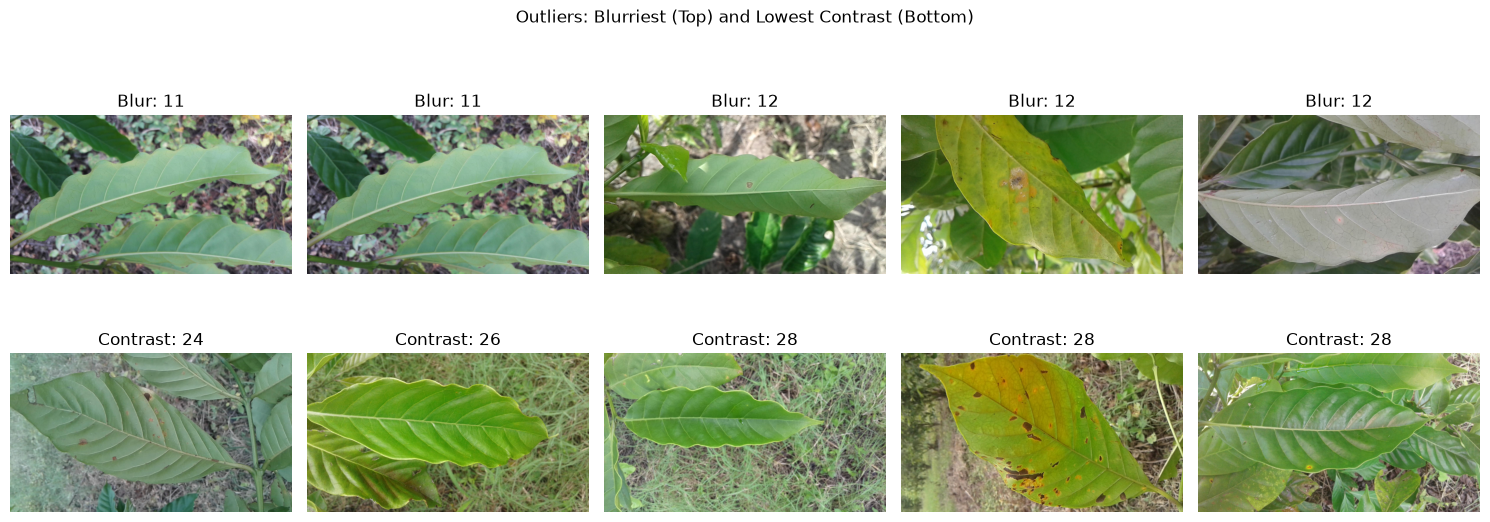

In [13]:
# Top 5 blurriest
blurriest = q_df.nsmallest(5, 'blur_score')
# Top 5 lowest contrast
lowest_contrast = q_df.nsmallest(5, 'contrast_score')

plt.figure(figsize=(15, 6))
plt.suptitle('Outliers: Blurriest (Top) and Lowest Contrast (Bottom)')
for i, (_, row) in enumerate(blurriest.iterrows()):
    img = cv2.cvtColor(cv2.imread(row['path']), cv2.COLOR_BGR2RGB)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Blur: {row['blur_score']:.0f}")
    plt.axis('off')

for i, (_, row) in enumerate(lowest_contrast.iterrows()):
    img = cv2.cvtColor(cv2.imread(row['path']), cv2.COLOR_BGR2RGB)
    plt.subplot(2, 5, i + 6)
    plt.imshow(img)
    plt.title(f"Contrast: {row['contrast_score']:.0f}")
    plt.axis('off')

plt.tight_layout()
plt.savefig('../plots/outlier_images.png')
plt.show()


## 14. Research Observations

**Observation 1:** Healthy images strongly dominate the dataset.
* This may bias the classifier towards the healthy class.
* **Recommendation:** Use weighted loss or data augmentation for minority classes.

**Observation 2:** Image resolutions are highly consistent across the dataset.
* **Recommendation:** No resizing inconsistency exists, but standardization to model input size (e.g., 224x224) is required.

**Observation 3:** Brightness and contrast vary due to real-world field captures.
* **Recommendation:** Apply color jittering and brightness normalization during augmentation.

**Observation 4:** Minor anomalies (outliers in blur or contrast) exist.
* **Recommendation:** Robust normalization pipelines will help smooth over environmental differences.


## 15. Conclusions

* **Dataset Strengths:** Standardized resolutions, realistic field conditions, and sufficient data for transfer learning.
* **Dataset Weaknesses:** Significant class imbalance.
* **Risks:** The model may overfit to the healthy class if not mitigated.
* **Recommendations:** Proceed to preprocessing with strict attention to stratification, and heavily augment minority classes.


## 16. Update Status

In [14]:
# Save findings
findings = {
    "imbalance_ratio": float(imbalance_ratio),
    "total_images": int(q_df.shape[0]),
    "average_blur": float(q_df['blur_score'].mean()),
    "average_contrast": float(q_df['contrast_score'].mean()),
    "recommendations": ["Weighted Loss", "Augmentation", "Resizing to 224x224"]
}
with open(reports_dir / 'eda_findings.json', 'w') as f:
    json.dump(findings, f, indent=4)

# Create markdown report
with open(reports_dir / 'EDA_Report.md', 'w') as f:
    f.write("# Exploratory Data Analysis (EDA) Report\n\n")
    f.write("## Quantitative Findings\n")
    for k, v in findings.items():
        if isinstance(v, list):
            f.write(f"- **{k}:** {', '.join(v)}\n")
        else:
            f.write(f"- **{k}:** {v}\n")
    f.write("\n## Conclusions\n")
    f.write("- The significant class imbalance requires intervention.\n")
    f.write("- Data quality is generally high with expected field variation in brightness and contrast.\n")

# Update Status
status['eda'] = True
with open(reports_dir / 'status.json', 'w') as f:
    json.dump(status, f, indent=4)

print("EDA completely finished. Status updated.")


EDA completely finished. Status updated.
